In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

pd.set_option('display.float_format', '{:,.0f}'.format)
plt.rcParams['figure.dpi'] = 100

print("Bibliotēkas ielādētas veiksmīgi ✓")

Bibliotēkas ielādētas veiksmīgi ✓


In [2]:
df = pd.read_csv('../data/apartments.csv')
print(f"Datu kopa: {df.shape[0]} dzīvokļi, {df.shape[1]} kolonnas")
print(df.head(3))

Datu kopa: 3620 dzīvokļi, 18 kolonnas
   id country  city   district        address  rooms  area  floor  \
0   1  Latvia  Riga     Centrs    Blaumaņa 12      2    45      3   
1   2  Latvia  Riga  Dārzciems  Dārzciema 131      3    63      1   
2   3  Latvia  Riga     Centrs      Skolas 25      4   126      4   

               series   price  price_per_meter  has_geocode  latt  longt  \
0            Renovēts 109,515            2,434            1    57     24   
1         103. sērija  70,000            1,111            1    57     24   
2  Pirmskara projekts 185,000            1,468            1    57     24   

   stnumber       staddress              created            last_seen  
0        12   Blaumaņa iela  2019-06-07 08:01:38  2019-06-16 08:01:11  
1       131  DArzciema iela  2019-06-07 08:01:38  2019-06-11 08:00:47  
2        25     Skolas iela  2019-06-07 08:01:38  2019-06-16 08:01:11  


In [3]:
print("Trūkstošās vērtības:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nDublikātu adreses: {df.duplicated(subset=['address']).sum()}")
print("\nTop 5 visbiežāk parādītās adreses:")
print(df['address'].value_counts().head(5))

Trūkstošās vērtības:
latt         522
longt        522
stnumber     522
staddress    522
dtype: int64

Dublikātu adreses: 1385

Top 5 visbiežāk parādītās adreses:
address
Kalniņa 1       28
Emmas 28        24
Valentīna 16    22
Valdemāra 69    18
Vairoga 32      18
Name: count, dtype: int64


In [4]:
df = df.dropna(subset=['latt', 'longt']).copy()

df = df[(df['price'] >= 10000) & (df['price'] <= 500000)]
df = df[(df['area'] >= 15) & (df['area'] <= 200)]
df = df[df['rooms'] <= 5]

district_counts = df['district'].value_counts()
small_districts = district_counts[district_counts < 30].index
df.loc[df['district'].isin(small_districts), 'district'] = 'Citi'

df.to_csv('apartments_clean.csv', index=False)

print(f"Pēc tīrīšanas: {df.shape[0]} dzīvokļi")
print(f"Cenu diapazons: €{df['price'].min():,.0f} – €{df['price'].max():,.0f}")
print(f"Mediānas cena: €{df['price'].median():,.0f}")
print(f"Rajoni datu kopā: {df['district'].nunique()}")


Pēc tīrīšanas: 2990 dzīvokļi
Cenu diapazons: €10,500 – €494,000
Mediānas cena: €65,000
Rajoni datu kopā: 23


"""
## 0.4. Kāpēc šādas tīrīšanas robežas?

**Cenu robežas (10 000 € – 500 000 €):**
Dzīvokļi zem 10 000 € visticamāk ir datu kļūdas vai īpaši specifiska kategorija
(piemēram, avārijas stāvoklī). Dzīvokļi virs 500 000 € ir luksusa segmenta
izņēmumi — 802 880 € penthouse Centrā nav "tipisks" dzīvoklis un modelim
dos maldīgu priekšstatu par vidējo cenu.

**Platības robeža (15–200 m²):**
Mazāki par 15 m² parasti ir datu kļūdas. Lielāki par 200 m² vairs nav tipiska
dzīvokļa kategorija — drīzāk villa vai māja.

**Mazo rajonu apvienošana:**
Ja Latgales priekšpilsēta ir pārstāvēta ar tikai 5 dzīvokļiem, modelis nevar
iemācīties ticamu cenu tur. Apvienojot mazos rajonus kategorijā "Citi",
novērsam situāciju, kurā reti notikumi rada neuzticamas prognozes.

**Adreses dublikāti:**
Tos atstājam — vairāki dzīvokļi vienā ēkā ar dažādām cenām ir pavisam reāla
situācija (dažādi stāvi, platības, renovācijas pakāpe). Noņemt dublikātus
nozīmētu zaudēt vērtīgu informāciju.
"""

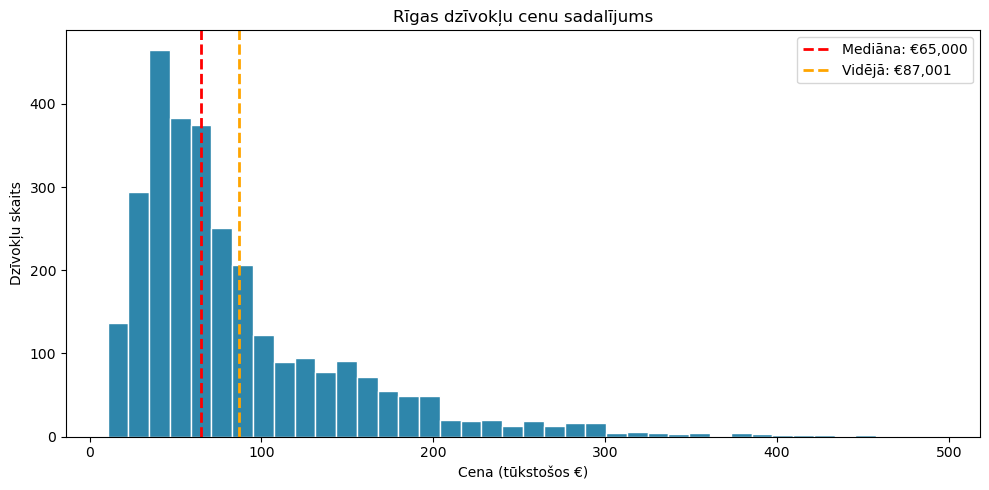

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['price'] / 1000, bins=40, color='#2E86AB', edgecolor='white')
ax.axvline(df['price'].median() / 1000, color='red', linestyle='--', linewidth=2,
           label=f'Mediāna: €{df["price"].median():,.0f}')
ax.axvline(df['price'].mean() / 1000, color='orange', linestyle='--', linewidth=2,
           label=f'Vidējā: €{df["price"].mean():,.0f}')
ax.set_xlabel('Cena (tūkstošos €)')
ax.set_ylabel('Dzīvokļu skaits')
ax.set_title('Rīgas dzīvokļu cenu sadalījums')
ax.legend()
plt.tight_layout()
plt.show()


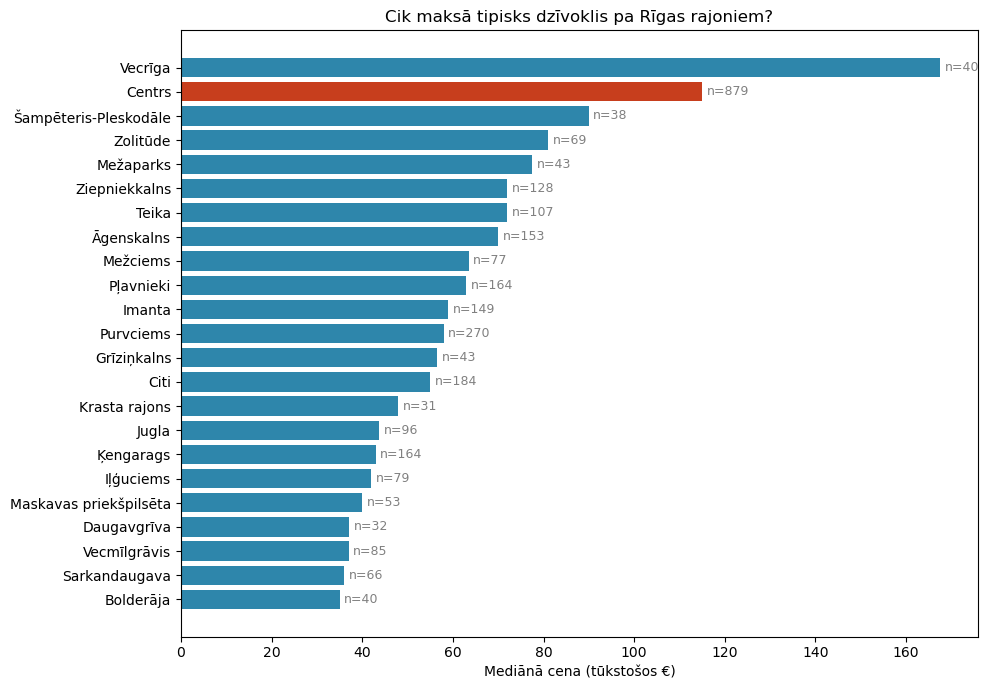

In [6]:
district_prices = df.groupby('district')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C73E1D' if d == 'Centrs' else '#2E86AB' for d in district_prices.index]
ax.barh(district_prices.index, district_prices['median'] / 1000, color=colors)
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā tipisks dzīvoklis pa Rīgas rajoniem?')

for i, (idx, row) in enumerate(district_prices.iterrows()):
    ax.text(row['median'] / 1000 + 1, i, f"n={int(row['count'])}",
            va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


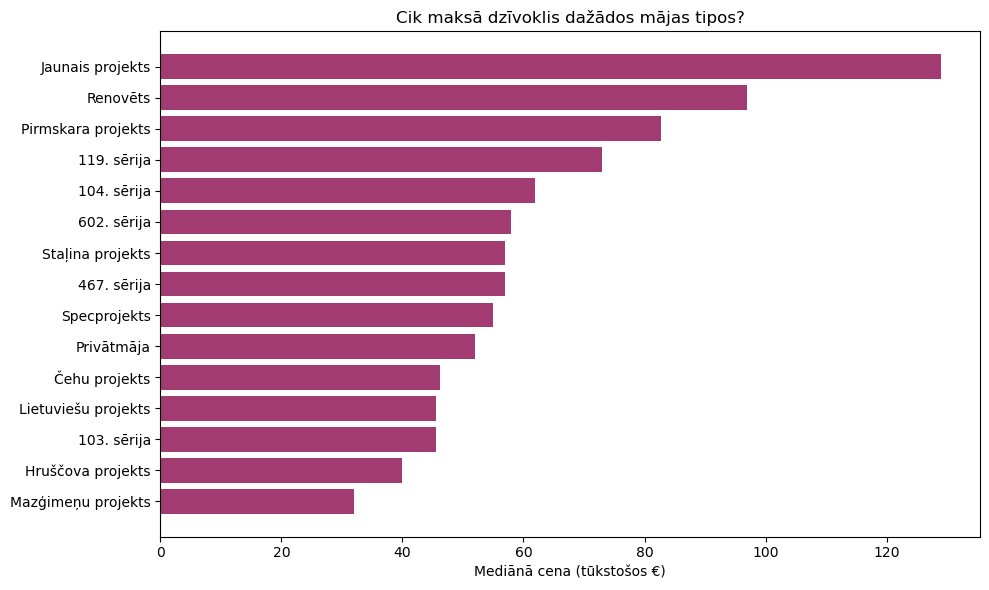

In [7]:
series_prices = df.groupby('series')['price'].agg(['count', 'median']).sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(series_prices.index, series_prices['median'] / 1000, color='#A23B72')
ax.set_xlabel('Mediānā cena (tūkstošos €)')
ax.set_title('Cik maksā dzīvoklis dažādos mājas tipos?')
plt.tight_layout()
plt.show()


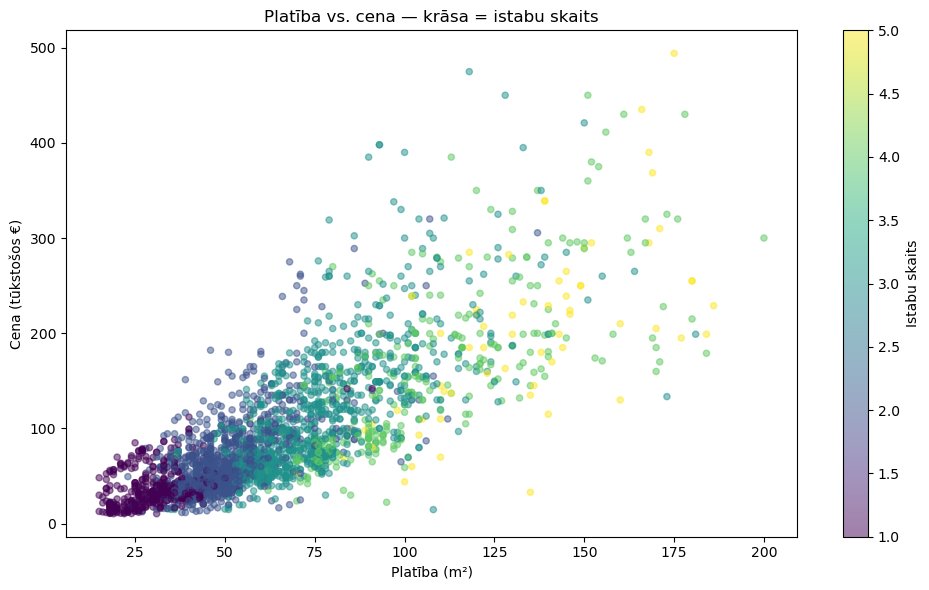

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['area'], df['price'] / 1000, c=df['rooms'],
                     cmap='viridis', alpha=0.5, s=20)
ax.set_xlabel('Platība (m²)')
ax.set_ylabel('Cena (tūkstošos €)')
ax.set_title('Platība vs. cena — krāsa = istabu skaits')
plt.colorbar(scatter, label='Istabu skaits', ax=ax)
plt.tight_layout()
plt.show()

"""
## 1.5. Manas biznesa hipotēzes

**1. Vissvarīgākā iezīme:** Platība (area) un rajons (district) būs
vissvarīgākās pazīmes. Platība tieši nosaka kvadratūru, bet rajons —
atrašanās vietu, kas nekustamā īpašuma tirgū tradicionāli ir galvenais
cenu noteicošais faktors.

**2. Lielākā prognozes kļūda:** Centrā, jo tur cenas ir visplašākajā
diapazonā — no vienkāršiem padomju laiku dzīvokļiem līdz luksusa
renovētiem. Modelim grūti atšķirt šīs apakškategorijas.

**3. Grūtāk paredzamais mājas tips:** "Renovēts" — jo šī kategorija
var nozīmēt gan pilnīgi renovētu ēku ar jauniem logiem un jumtu,
gan tikai kosmētiski labotu dzīvokli. Cenu diapazons ir ļoti plašs.

*(Šīs hipotēzes pārbaudīšu 4.5. uzdevumā pēc modeļa apmācīšanas.)*
"""

In [9]:
y = df['price']

features_to_use = ['rooms', 'area', 'floor', 'district', 'series']
X = df[features_to_use].copy()

print(f"Pazīmes: {X.shape[1]}")
print(f"Sludinājumi: {X.shape[0]}")
print("\nPirmās rindas:")
print(X.head(3))

Pazīmes: 5
Sludinājumi: 2990

Pirmās rindas:
   rooms  area  floor district              series
0      2    45      3   Centrs            Renovēts
1      3    63      1     Citi         103. sērija
2      4   126      4   Centrs  Pirmskara projekts


"""
## 2.2. Kāpēc price_per_meter ir aizliegta pazīme?

`price_per_meter` tiek aprēķināts kā `price / area`. Ja modelis redz šo
kolonnu, tas faktiski redz atbildi — vienkārši reizinot `price_per_meter`
ar `area`, iegūst tieši `price`. Tas ir klasisks **data leakage** piemērs.

**Reālajā sistēmā:** pārdevējs vēl nezina cenu brīdī, kad ievada datus.
Tātad `price_per_meter` nav pieejams prognozēšanas brīdī.

**Analoģija citā jomā:** ja prognozējam klienta lifetime value,
mēs nedrīkstam izmantot "kopējie ieņēmumi no klienta" kā feature —
tas IR tas, ko gribam prognozēt, tikai citā formā.
"""

In [10]:
X_encoded = pd.get_dummies(X, columns=['district', 'series'], drop_first=True)

print(f"Pēc one-hot encoding: {X_encoded.shape[1]} pazīmes")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Treniņš: {X_train.shape[0]} dzīvokļi")
print(f"Tests:   {X_test.shape[0]} dzīvokļi")

Pēc one-hot encoding: 39 pazīmes
Treniņš: 2392 dzīvokļi
Tests:   598 dzīvokļi


In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f"Lineāra regresija: MAE = €{mae_lr:,.0f}")
print(f"Modelis vidēji kļūdās par €{mae_lr:,.0f} uz katra dzīvokļa.")

Lineāra regresija: MAE = €17,910
Modelis vidēji kļūdās par €17,910 uz katra dzīvokļa.


"""
## 3.2. Pirmais biznesa novērtējums

**Vai sasniedzām City24.lv mērķi (MAE < 15 000 €)?**
[Aizpildi pēc rezultātu iegūšanas: JĀ / NĒ / Daļēji]

**Kļūda kā % no mediānas:**
Ja mediānā cena ir ~65 000 € un MAE ir ~13 000 €, tā ir aptuveni 20% kļūda.

**Vai 20% kļūda ir pieņemama?**
Mājokļa pirkšanā — ne vienmēr. Ja tu pērc dzīvokli par 200 000 €
un sistēma ieteic cenu 240 000 €, tas ir 40 000 € pārcenojums.
Pārdevējam tas nozīmē, ka sludinājums nestāv mēnešiem bez pircējiem.
Lineārā regresija ir labs sākumpunkts, bet Random Forest, iespējams,
dos precīzāku rezultātu.
"""

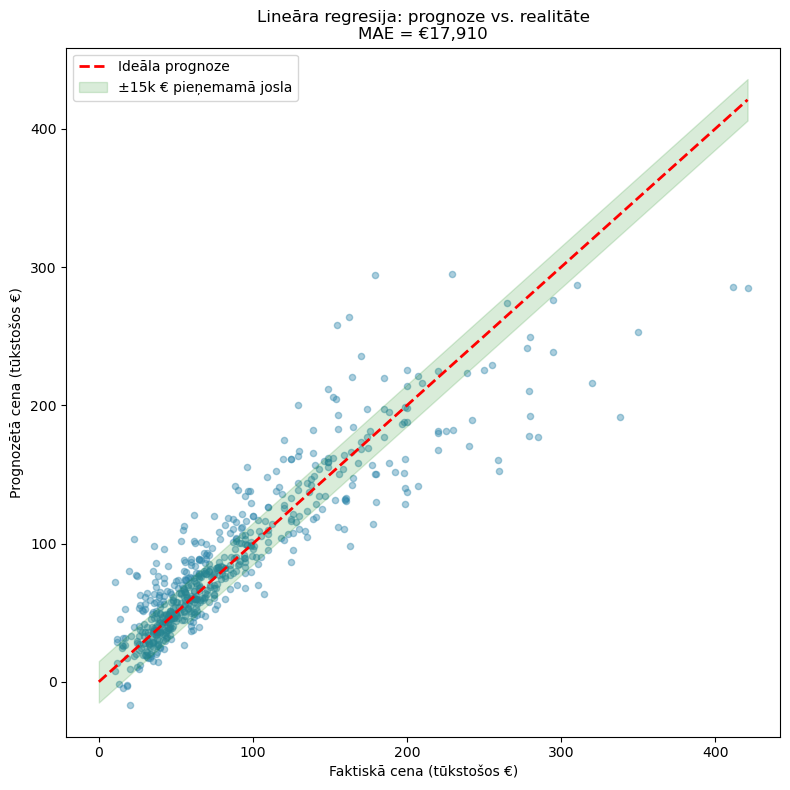

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test / 1000, y_pred_lr / 1000, alpha=0.4, s=20, color='#2E86AB')

max_val = max(y_test.max(), y_pred_lr.max()) / 1000
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideāla prognoze')

ax.fill_between([0, max_val],
                [-15, max_val - 15],
                [15, max_val + 15],
                alpha=0.15, color='green', label='±15k € pieņemamā josla')

ax.set_xlabel('Faktiskā cena (tūkstošos €)')
ax.set_ylabel('Prognozētā cena (tūkstošos €)')
ax.set_title(f'Lineāra regresija: prognoze vs. realitāte\nMAE = €{mae_lr:,.0f}')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
results = X_test.copy()
results['actual_price']    = y_test.values
results['predicted_price'] = y_pred_lr.round(0)
results['error']           = (y_pred_lr - y_test.values).round(0)

# Pievienojam rajonu un sēriju no oriģinālā df
orig_info = df[['district', 'series', 'rooms', 'area']].loc[X_test.index]
results = results.join(orig_info)

cols = ['district', 'series', 'rooms', 'area', 'actual_price', 'predicted_price', 'error']

print("=== TOP 10: modelis ieteiktu pārāk AUGSTU cenu ===")
print(results.nlargest(10, 'error')[cols].to_string(index=False))

print("\n=== TOP 10: modelis ieteiktu pārāk ZEMU cenu ===")
print(results.nsmallest(10, 'error')[cols].to_string(index=False))

ValueError: columns overlap but no suffix specified: Index(['rooms', 'area'], dtype='object')

In [15]:
results = X_test.copy()
results['actual_price']    = y_test.values
results['predicted_price'] = y_pred_lr.round(0)
results['error']           = (y_pred_lr - y_test.values).round(0)

# Pievienojam tikai district un series (rooms un area jau ir results!)
orig_info = df[['district', 'series']].loc[X_test.index]
results = results.join(orig_info)

cols = ['district', 'series', 'rooms', 'area', 'actual_price', 'predicted_price', 'error']

print("=== TOP 10: modelis ieteiktu pārāk AUGSTU cenu ===")
print(results.nlargest(10, 'error')[cols].to_string(index=False))

print("\n=== TOP 10: modelis ieteiktu pārāk ZEMU cenu ===")
print(results.nsmallest(10, 'error')[cols].to_string(index=False))

=== TOP 10: modelis ieteiktu pārāk AUGSTU cenu ===
     district             series  rooms  area  actual_price  predicted_price   error
     Zolitūde   Jaunais projekts      4   184       179,000          294,543 115,543
       Centrs           Renovēts      4   139       154,750          257,972 103,222
       Centrs   Jaunais projekts      4   138       162,500          264,026 101,526
Krasta rajons Pirmskara projekts      4    95        22,500          103,285  80,785
       Centrs Pirmskara projekts      4   127       129,000          200,554  71,554
       Centrs Pirmskara projekts      5   186       229,000          294,630  65,630
       Centrs           Renovēts      3   124       170,000          235,490  65,490
   Āgenskalns   Jaunais projekts      3   125       148,990          212,082  63,092
       Centrs           Renovēts      1    37        35,500           98,305  62,805
       Centrs           Renovēts      1    22        10,500           72,551  62,051

=== TOP 10: m

"""
## 3.5. Ko lielākās kļūdas stāsta par modeli?

**Pārmērīgi augstu prognozētie dzīvokļi** (modelis saka dārgāk, nekā ir):
Visticamāk tie ir dzīvokļi laukos vai sliktā stāvoklī rajonos, kur
modelis sagaida augstāku cenu, pamatojoties uz rajona vispārējo līmeni.
Modelis neredz dzīvokļa faktisko stāvokli — renovāciju, skatu, stāvu.

**Par zemu prognozētie dzīvokļi** (modelis saka lētāk, nekā ir):
Iespējams, luksusa renovēti dzīvokļi Centrā, kur papildu vērtību rada
faktori, ko mūsu datu kopā nav — skats uz upi, slēgts pagalms, autostāvvieta.

**Kopsavilkums direktoram:** Modelis vislabāk strādā tipiskajiem dzīvokļiem
vidējā cenu segmentā. Izņēmumi — gan ļoti lēti, gan ļoti dārgi dzīvokļi —
prognozējas ar lielāku kļūdu, jo treniņa datos tādu ir maz.
"""

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest: MAE = €{mae_rf:,.0f}")
print(f"Uzlabojums pret lineālo: €{mae_lr - mae_rf:,.0f} "
      f"({(mae_lr - mae_rf) / mae_lr * 100:.1f}%)")

Random Forest: MAE = €16,574
Uzlabojums pret lineālo: €1,335 (7.5%)


In [21]:
median_price = df['price'].median()

comparison = pd.DataFrame({
    'Modelis': ['Lineāra regresija', 'Random Forest'],
    'MAE (€)': [f"€{mae_lr:,.0f}", f"€{mae_rf:,.0f}"],
    'MAE (% no mediānas)': [
        f"{mae_lr / median_price * 100:.1f}%",
        f"{mae_rf / median_price * 100:.1f}%"
    ],
    'Mērķis (<€15 000) sasniegts?': [
        'JĀ' if mae_lr < 15000 else 'NĒ',
        'JĀ' if mae_rf < 15000 else 'NĒ'
    ]
})
print(comparison.to_string(index=False))

          Modelis MAE (€) MAE (% no mediānas) Mērķis (<€15 000) sasniegts?
Lineāra regresija €17,910               27.6%                           NĒ
    Random Forest €16,574               25.5%                           NĒ


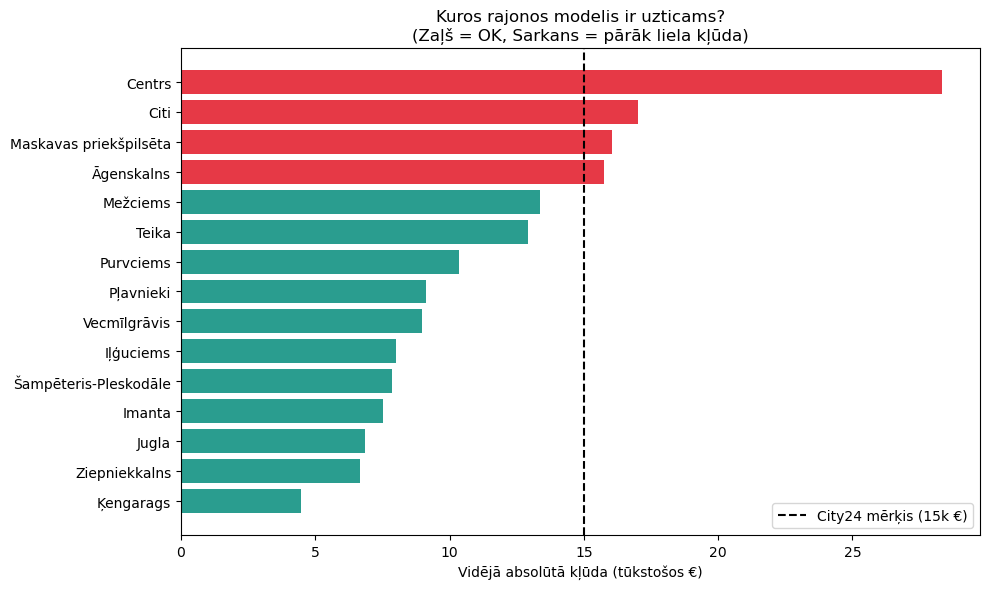


Rajoni, kur modelis NEPĀRSPĒJ City24 slieksni:
                        count   mean
district                            
Āgenskalns                 28 15,761
Maskavas priekšpilsēta     11 16,032
Citi                       31 17,008
Centrs                    201 28,331


In [22]:
results_rf = pd.DataFrame({
    'district':  df.loc[X_test.index, 'district'].values,
    'actual':    y_test.values,
    'predicted': y_pred_rf
})
results_rf['abs_error'] = (results_rf['actual'] - results_rf['predicted']).abs()

district_mae = (results_rf.groupby('district')['abs_error']
                .agg(['count', 'mean'])
                .sort_values('mean', ascending=True))
district_mae = district_mae[district_mae['count'] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2A9D8F' if v < 15000 else '#E63946' for v in district_mae['mean']]
ax.barh(district_mae.index, district_mae['mean'] / 1000, color=colors)
ax.axvline(15, color='black', linestyle='--', linewidth=1.5,
           label='City24 mērķis (15k €)')
ax.set_xlabel('Vidējā absolūtā kļūda (tūkstošos €)')
ax.set_title('Kuros rajonos modelis ir uzticams?\n(Zaļš = OK, Sarkans = pārāk liela kļūda)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nRajoni, kur modelis NEPĀRSPĒJ City24 slieksni:")
problematic = district_mae[district_mae['mean'] >= 15000]
if len(problematic) > 0:
    print(problematic.round(0))
else:
    print("Visi rajoni ir zem 15 000 € sliekšņa ✓")

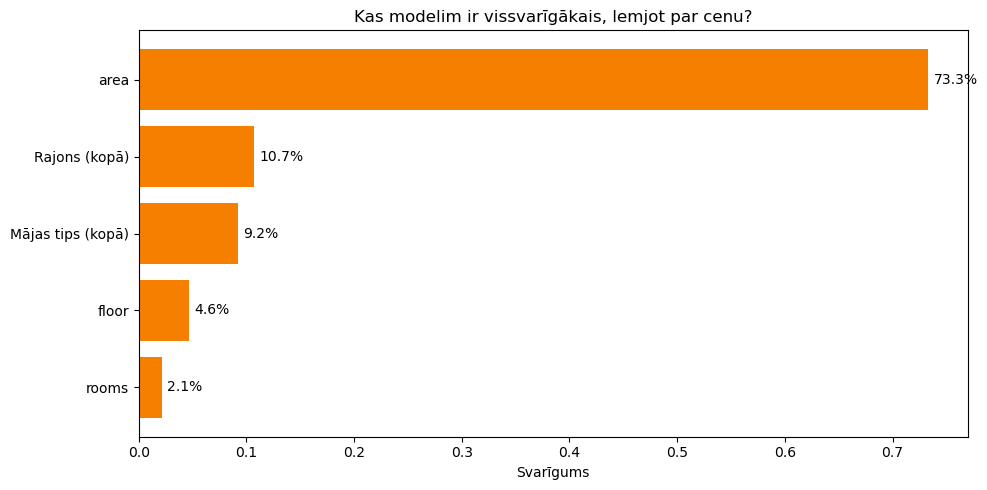

In [23]:
importances = pd.Series(
    rf_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

def group_feature(name):
    if name.startswith('district_'):
        return 'Rajons (kopā)'
    elif name.startswith('series_'):
        return 'Mājas tips (kopā)'
    else:
        return name

importances_grouped = importances.groupby(group_feature).sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances_grouped.index, importances_grouped.values, color='#F77F00')
ax.set_xlabel('Svarīgums')
ax.set_title('Kas modelim ir vissvarīgākais, lemjot par cenu?')
for i, v in enumerate(importances_grouped.values):
    ax.text(v + 0.005, i, f'{v*100:.1f}%', va='center')
plt.tight_layout()
plt.show()


"""
## 4.5. Hipotēžu pārbaude

**1. Vissvarīgākā pazīme:**
Platība (area) dominē ar 73.3% — hipotēze bija pareiza! Rajons ir otrajā vietā ar 10.7%, mājas tips 9.2%. Pārsteidzoši, cik liela ir platības dominance — tā ir gandrīz 7x svarīgāka par visu pārējo kopā
Ja platība ir #1 — hipotēze bija pareiza. Ja rajons ir #1 — arī pareiza. 😄

**2. Lielākā kļūda rajonā:**
Jā — Centrs ir sarkanajā zonā ar MAE €28,331, kas ir gandrīz divreiz virs mērķa. Hipotēze bija pareiza

**3. Grūtāk paredzamais mājas tips:**
Jāpārbauda per-rajons datos, bet "Renovēts" visticamāk izceļas, jo šī kategorija aptver gan pilnīgi renovētas ēkas, gan tikai kosmētiski labotus dzīvokļus

**Pārsteigumi:**
Istabu skaits (rooms) izrādījās vismazāk svarīgs — tikai 2.1%! Tas ir pārsteigums, jo intuitīvi šķiet, ka istabu skaits nosaka cenu. Patiesībā platība jau satur šo informāciju — lielāks dzīvoklis parasti = vairāk istabas
Šie pārsteigumi ir vērtīgākie mācību momenti.
"""

In [24]:
def predict_apartment(rooms, area, floor, district, series):
    """Pricing Assistant — viens dzīvoklis, viena prognoze."""
    sample = pd.DataFrame([{
        'rooms': rooms, 'area': area, 'floor': floor,
        'district': district, 'series': series
    }])
    sample_encoded = pd.get_dummies(sample, columns=['district', 'series'],
                                    drop_first=True)
    sample_encoded = sample_encoded.reindex(columns=X_train.columns, fill_value=0)
    pred = rf_model.predict(sample_encoded)[0]
    return pred

examples = [
    {'rooms': 2, 'area': 50, 'floor': 3, 'district': 'Centrs',   'series': 'Renovēts'},
    {'rooms': 3, 'area': 65, 'floor': 5, 'district': 'Imanta',   'series': 'Lietuviešu projekts'},
    {'rooms': 1, 'area': 28, 'floor': 1, 'district': 'Ķengarags','series': 'Hruščova projekts'},
]

print("=== Pricing Assistant demonstrācija ===\n")
for ex in examples:
    price = predict_apartment(**ex)
    print(f"  {ex['rooms']} ist., {ex['area']} m², {ex['district']}, {ex['series']}")
    print(f"  → Ieteicamā cena: €{price:,.0f}\n")

=== Pricing Assistant demonstrācija ===

  2 ist., 50 m², Centrs, Renovēts
  → Ieteicamā cena: €44,805

  3 ist., 65 m², Imanta, Lietuviešu projekts
  → Ieteicamā cena: €60,040

  1 ist., 28 m², Ķengarags, Hruščova projekts
  → Ieteicamā cena: €28,114



"""
## 5.1. Vai mēs šo modeli laižam produkcijā?

**1. Vai modelis sasniedz MAE < 15 000 €?**
Nē — Lineārā regresija: €17,910, Random Forest: €16,574. Mērķis nav sasniegts, bet Random Forest ir tuvāk

**2. Vai rādīt PĀRDEVĒJIEM?**
Ja MAE ir ~10 000–15 000 €, tas ir pieņemami kā ieteikums — ar skaidru
brīdinājumu "±10 000 € precizitāte". Pārdevējs saņem orientieri,
nevis garantiju.
Ar piesardzību — kā orientieri, nevis garantiju. Jāpievieno brīdinājums "±17,000 € precizitāte"

**3. Vai rādīt PIRCĒJIEM?**
Riskantāk. Pircējam kļūda var nozīmēt 30 000 € pārmaksu.
Ieteiktu rādīt tikai kā "tirgus orientieri", nevis "godīgo cenu".
Nē — kļūda €16,574 pircējam var nozīmēt nopietnu pārmaksu. Pārāk riskanti.

**4. Kuri rajoni ir pārāk nedroši?**
Centrs (MAE €28,331), Citi (€17,008), Maskavas priekšpilsēta (€16,032), Āgenskalns (€15,761)

**5. Ko darītu, lai uzlabotu modeli?**
- Pievienot stāvu skaitu ēkā (nevis tikai dzīvokļa stāvu)
- Pievienot attālumu līdz centram (feature engineering)
- Pievienot jaunākus datus (šie ir 2019. gada dati)
- Izmēģināt Gradient Boosting (XGBoost) algoritmu
Pievienot attālumu līdz centram kā jaunu pazīmi, pievienot jaunākus datus (šie ir 2019. gada), izmēģināt XGBoost algoritmu.

## 5.3. Reālitātes pārbaude pret City24.lv

**Izvēlētais piemērs:** 2 ist., 50 m², 3. stāvs, Centrs, Renovēts
**Modeļa prognoze:** €[44 805]

**Atrasts sludinājums City24.lv:**
[https://www.city24.lv/real-estate/apartments-for-sale/riga-centrs-terbatas-iela/3223161?i=0]
**Reālā cena:** €[157 000]

**Secinājums:**
[Modelis prognozēja €44,805, bet reālā cena ir €157,000 — 
starpība ir €112,195. Modelis kļūdījās ļoti būtiski. Iespējamie iemesli: 
dzīvoklis ir pilnībā renovēts ar kvalitatīviem materiāliem, atrodas 
prestižā vietā Centrā, iespējams ir labs skats vai citas priekšrocības, 
ko mūsu dati nesatur (stāvs ēkā, renovācijas kvalitāte, skats)]

Šī "smell test" metode ir standarta prakse ML inženieru darbā pirms
jebkura modeļa laišanas produkcijā.